In [ ]:
# Early Stopping

# Early Stopping

Совсем другой способ регуляризации итеративных алгоритмов обучения (таких как градиентный спуск) — остановить обучение, как только ошибка на валидации достигает минимума. Это популярная техника, которая называется **early stopping** («ранняя остановка»).

Пример: сложная модель (полиномиальная регрессия высокой степени) обучается батч-градиентным спуском на квадратичном датасете. По мере эпох ошибка модели (RMSE) на обучающей выборке падает, вместе с ней падает и ошибка на валидационной выборке. Но через какое-то время ошибка на валидации перестаёт уменьшаться и начинает расти обратно — это признак того, что модель начала переобучаться.

С early stopping вы просто останавливаете обучение в тот момент, когда ошибка на валидации была минимальной. Джеффри Хинтон назвал эту технику «прекрасным бесплатным обедом» (beautiful free lunch) — настолько она простая и эффективная.

При стохастическом и мини-batch градиентном спуске кривые ошибок не такие гладкие, и понять, что минимум уже достигнут, сложнее. Один из вариантов решения: останавливаться только после того, как ошибка на валидации была выше минимума в течение какого-то времени (когда вы уверены, что лучше уже не будет), а затем откатить параметры модели к точке, где ошибка на валидации была минимальной.

Ниже — базовая реализация early stopping.

best_valid_rmse 1.4099344710854789
best model SGDRegressor(eta0=0.002, penalty=None, random_state=42)
val_errors [15.356432653185353, 6.27559605535807, 9.418153498245593]


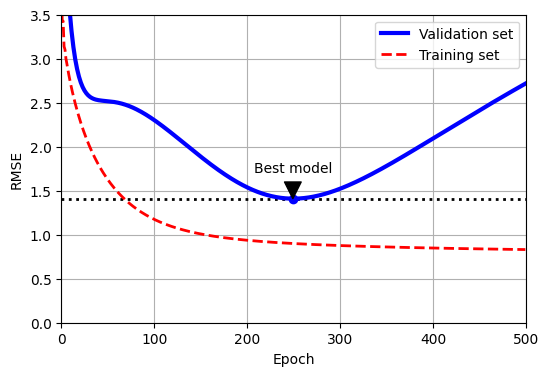

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDRegressor

# extra code – creates the same quadratic dataset as earlier and splits it
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(
    PolynomialFeatures(degree=90, include_bias=False), StandardScaler()
)

X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float("inf")
best_model: SGDRegressor = None
train_errors, val_errors = [], []  # extra code – it's for the figure below

for epoch in range(n_epochs):
    # Сначала на маленькой части учимся (Не на всем датасете!) perform incremental learning
    sgd_reg.partial_fit(X_train_prep, y_train)
    
    # Тут же замеряем результаты на valid (на всем датасете!)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    valid_error = root_mean_squared_error(y_valid, y_valid_predict)
    # extra code – we evaluate the train error and save it for the figur
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    # Track errors
    val_errors.append(valid_error)
    train_errors.append(train_error)

    if valid_error < best_valid_rmse:
        best_valid_rmse = valid_error
        best_model = deepcopy(sgd_reg)

print("best_valid_rmse", best_valid_rmse)
print("best model", best_model)
print("val_errors", val_errors[0:3])

# argmin отдать индекс минимального числа в массив
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
# Добавить текст аннотацию над линией по центру со стрелкой
plt.annotate(
    "Best model",
    xy=(best_epoch, best_valid_rmse),
    xytext=(best_epoch, best_valid_rmse + 0.3),
    ha="center",
    arrowprops=dict(facecolor="black", shrink=0.65),
)
# Отображение линии по центру
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
# Отображение точки где нашлось самое лучшее
plt.plot(best_epoch, best_valid_rmse, "bo")
# Рисуем линии по ошибкам
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
# Закрепить легенду справа вверху
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
# Задать отображаемые границы графика [x_min, x_max, y_min, y_max]
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()
plt.show()

# Early Stopping — что делает код

Код сначала добавляет полиномиальные признаки и масштабирует все входные признаки — и для обучающей, и для валидационной выборки (предполагается, что исходный training set уже разбит на меньший train и validation).

Затем создаётся модель `SGDRegressor` без регуляризации и с маленьким learning rate.

В цикле обучения вызывается `partial_fit()` вместо `fit()`, чтобы делать инкрементальное (пошаговое) обучение. На каждой эпохе измеряется RMSE на валидационной выборке. Если оно ниже самого низкого RMSE, увиденного до этого, — сохраняется копия модели в переменную `best_model`.

Эта реализация на самом деле **не останавливает** обучение — она просто позволяет после окончания обучения вернуться к лучшей из всех промежуточных моделей.

Важный момент: модель копируется через `copy.deepcopy()`, потому что этот метод копирует и гиперпараметры модели, и уже выученные параметры. А вот `sklearn.base.clone()` копирует **только** гиперпараметры, без выученных весов.

[3.45770384]


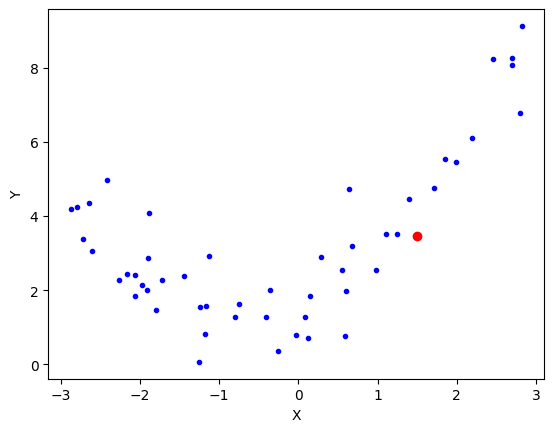

In [53]:
# Использование лучшей модели для предсказания
X_new = np.array([[1.5]])
X_new_prep = preprocessing.transform(X_new)
prediction = best_model.predict(X_new_prep)
print(prediction)

plt.plot(X_train, y_train, "b.")
plt.plot(X_new, prediction, "ro")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()